# LUMEDistgenImpactModel Creation
The object `LUMEDistgenImpactModel` and associated classes are included to provide a batteries-included lume-model object for Impact-T and Distgen that works out of the box. It includes configurable defaults driven by pydantic objects and the generated control variables can be easily extended and overidden as user requirements dictate.

In this notebook, we will explore creating a `LUMEDistgenImpactModel` from a loaded Impact-T object and Distgen Generator, then add user-defined actions to it.

In [1]:
from impact import Impact
from impact.model.distgen.distgen_impact_model import LUMEDistgenImpactModel
from impact.model.actions import WritableImpactAction, EleAction
from impact.model.config import (
    VariableMappingConfig,
    ElementsConfig,
    StatsConfig,
    ParticlesConfig,
    RunInfoConfig,
)
from distgen import Generator

from lume.variables import ScalarVariable, NDVariable, ParticleGroupVariable
import matplotlib.pyplot as plt

In [2]:
# Load the distgen generator object
gen = Generator("templates/lcls_injector/distgen.yaml")
gen["n_particle"] = 10000

In [3]:
# Load LCLS Impact-T lattice
impact = Impact("templates/lcls_injector/ImpactT.in")
impact.header["Np"] = 10000
impact.header["Nx"] = 16
impact.header["Ny"] = 16
impact.header["Nz"] = 16
impact.header["Dt"] = 5e-13

# Turn Space Charge off. Both these syntaxes work
impact.header["Bcurr"] = 0
impact["header:Bcurr"] = 0

# Other switches
impact.timeout = None

# Switches for MPI
impact.numprocs = 0  # Auto-select

impact.run()

In [4]:
# Dict with element name mappings from SLAC machine name to impact name
ele_name_mappings = {"QUAD:IN20:425": "QE01"}

# Configure automatic variable and action creation from Impact-T instance
imp_config = VariableMappingConfig(
    elements=ElementsConfig(
        pattern="{name}:{attrib}",
        name_mappings=ele_name_mappings,
    ),
    stats=StatsConfig(pattern="STATS:{name}"),
    particles=ParticlesConfig(pattern="PAR:{name}"),
    run_info=RunInfoConfig(pattern="RUNINFO:{key}"),
)

In [5]:
# Generate model automatically creating
model = LUMEDistgenImpactModel.from_objects(
    gen,
    impact,
    impact_config=imp_config,
)


# Show default loaded variables, can control names and inclusion of all attributes from `VariableMappingConfig` object
[var for var in model.supported_variables.values() if "IN20" in var.name]

[]

In [6]:
# Look at the stats keys
[
    (var.name, var.shape)
    for var in model.supported_variables.values()
    if isinstance(var, NDVariable) and var.read_only
]

[('STATS:mean_kinetic_energy', (881,)),
 ('STATS:mean_x', (881,)),
 ('STATS:mean_y', (881,)),
 ('STATS:mean_z', (881,)),
 ('STATS:sigma_x', (881,)),
 ('STATS:sigma_y', (881,)),
 ('STATS:sigma_z', (881,)),
 ('STATS:norm_emit_x', (881,)),
 ('STATS:norm_emit_y', (881,)),
 ('STATS:norm_emit_z', (881,))]

In [7]:
# Look at the particles keys
[
    var.name
    for var in model.supported_variables.values()
    if isinstance(var, ParticleGroupVariable)
]

['PAR:initial_particles', 'PAR:final_particles', 'PAR:YAG02']

## Actions
In the included model object, interactions with the underlying simulation are controlled through "actions" which couple a control variable with the methods that control what it does to the simulator. There are two types of actions: `ImpactAction` and `WritableImpactAction` depending on whether it supports writable variables or not. Simply implement the `get` and `set` methods and register the action including your control variables for it to be served from the model.

We will add a few example actions that extend the model with user-defined functionality here.

In [8]:
# Add custom attribute to the quads - field integral
class BCTRLAction(WritableImpactAction):
    # It is recommended to override the generic variable field to get type validation for the variable type(s) your action supports
    var: ScalarVariable

    # The name of the element this control variable acts on
    ele_name: str

    def _get(self, impact):
        # Example calculation of quantity similar to field integral
        integral = (
            impact.ele[self.ele_name]["b1_gradient"] * impact.ele[self.ele_name]["L"]
        )
        print(f"Read ({self.ele_name}) integral = {integral:.2f}")
        return integral

    def _set(self, impact, value):
        b1_grad = value / impact.ele[self.ele_name]["L"]
        print(f"Setting ({self.ele_name}) b1_grad = {b1_grad:.2f}")
        impact.ele[self.ele_name]["b1_gradient"] = b1_grad


# Go through the lattice and create the action and register with model for each quadrupole we see
inv_name_map = {v: k for k, v in ele_name_mappings.items()}
ctrl_vars = []
for ele in impact.lattice:
    name = ele["name"]
    if ele["type"] == "quadrupole":
        model.register_action(
            BCTRLAction(
                var=ScalarVariable(
                    name=inv_name_map.get(name, name) + ":BCTRL", unit="kG"
                ),
                ele_name=name,
            )
        )

Read (SQ01) integral = 0.00
Read (CQ01) integral = 0.00
Read (QA01) integral = 0.38
Read (QA02) integral = -0.38
Read (QE01) integral = 0.04
Read (QE02) integral = 0.03
Read (QE03) integral = -0.54
Read (QE04) integral = 0.61


In [9]:
# Example of more complicated action containing additional stored data
class ScaledEleAction(WritableImpactAction):
    # It is recommended to override the generic variable field to get type validation for the variable type(s) your action supports
    var: ScalarVariable

    # The element name and attribute the control variable acts on
    ele_name: str
    attribute: str

    # Define a linear transformation mapping simulation units to control system units
    scale: float
    offset: float

    def _get(self, impact):
        return self.scale * impact.ele[self.ele_name][self.attribute] + self.offset

    def _set(self, impact, value):
        impact.ele[self.ele_name][self.attribute] = (value - self.offset) / self.scale


# Override all existing quad actions with a 10% scaling factor
for action in model.impact_actions:
    if isinstance(action, EleAction):
        if impact.ele[action.ele_name]["type"] == "quadrupole":
            model.register_action(
                ScaledEleAction(
                    var=action.var,
                    ele_name=action.ele_name,
                    attribute=action.attribute,
                    scale=1.1,
                    offset=0.0,
                )
            )

## Usage
In this section we will explore getting some outputs from using the lume-model interface. We will then modify the system's state and observe the outputs once more.

Text(0, 0.5, 'Beam Energy (MeV, Orange)')

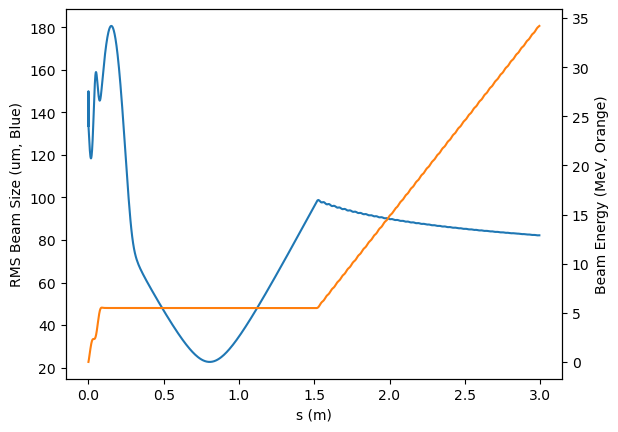

In [10]:
# Get the stats object
stats = model.get(["STATS:sigma_x", "STATS:mean_z", "STATS:mean_kinetic_energy"])
plt.plot(stats["STATS:mean_z"], 1e6 * stats["STATS:sigma_x"], c="C0")
plt.xlabel("s (m)")
plt.ylabel("RMS Beam Size (um, Blue)")
plt.twinx()
plt.plot(stats["STATS:mean_z"], 1e-6 * stats["STATS:mean_kinetic_energy"], c="C1")
plt.ylabel("Beam Energy (MeV, Orange)")

Read (SQ01) integral = 0.00
Read (CQ01) integral = 0.00
Read (QA01) integral = 0.38
Read (QA02) integral = -0.38
Read (QE01) integral = 0.04
Read (QE02) integral = 0.03
Read (QE03) integral = -0.54
Read (QE04) integral = 0.61


Text(0, 0.5, 'Beam Energy (MeV, Orange)')

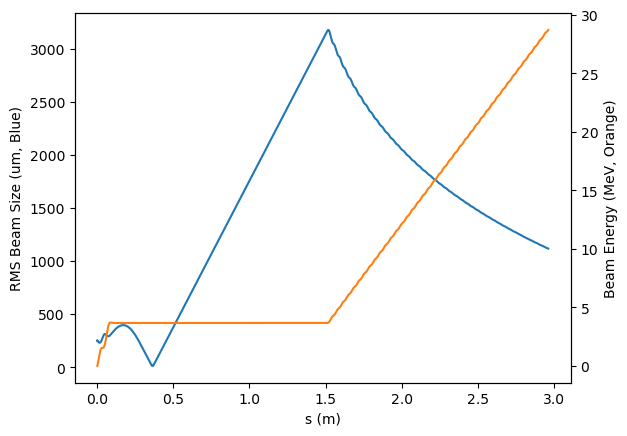

In [11]:
# Turn down the gun's field (this will rerun Distgen and Impact-T)
model.set({"GUN:rf_field_scale": 32291431.56499891})

# Get the stats object
stats = model.get(["STATS:sigma_x", "STATS:mean_z", "STATS:mean_kinetic_energy"])
plt.plot(stats["STATS:mean_z"], 1e6 * stats["STATS:sigma_x"], c="C0")
plt.xlabel("s (m)")
plt.ylabel("RMS Beam Size (um, Blue)")
plt.twinx()
plt.plot(stats["STATS:mean_z"], 1e-6 * stats["STATS:mean_kinetic_energy"], c="C1")
plt.ylabel("Beam Energy (MeV, Orange)")